# 1. Preprocess

## 1.1. Images

- Crop images to remove unnecessary white margins.
- Resize images to a fixed size (e.g., 384x384 pixels) while maintaining aspect ratio (thumbnailing + padding).
- Convert images to grayscale to reduce complexity (but the channel dim is still 3).
- Apply data augmentation techniques when training.
- Normalize with mean and standard deviation of the dataset (UniMER).
- Convert images to tensors.

## 1.2. LaTeX Sequences

- Tokenize LaTeX sequences using a custom tokenizer. Convert LaTeX commands and symbols into unique tokens.
- Each token is mapped to a unique integer ID.

# 2. Model Architecture
## 2.1. Encoder: HGNet-V2

The encoder is a CNN based on HGNet-V2 architecture, designed for efficient feature extraction from images. It uses hierarchical grouping of convolutional layers with layer aggregation and squeeze-and-excitation mechanisms.
- ConvBNAct: Convolution + BatchNorm + ReLU
- LightConvBNAct: Depthwise Separable Convolution + BatchNorm + ReLU

The encoder consists of a Stem followed by 4 Stages.

- Stem Block (StemBlock):

  - Function: Performs aggressive initial downsampling to reduce the spatial resolution of the input image (384x384) early on, saving computation for later stages.
  - Structure: It consists of multiple ConvBNAct layers (Convolution + BatchNorm + ReLU) and a MaxPool layer.
    - Input shape: (B, 3, 384, 384)
    - Output shape: (B, 48, 96, 96)


- Hierarchical Stages (HG_Stage):

  - The network has 4 stages.

  - The Building Block: HG Block (HG_Block):
    - Lightweight Convolution: It uses LightConvBNAct, which implements Depthwise Separable Convolutions (1x1 Pointwise Conv followed by a grouped KxK Depthwise Conv). This reduces parameter count and computation compared to standard convolutions.
    - Layer Aggregation: Inside a block, it stacks multiple layers. Crucially, it concatenates the outputs of all layers in the block (torch.cat(output, dim=1)).
    - Squeeze-and-Excitation: After concatenation, it uses 1x1 convolutions (aggregation_squeeze_conv and aggregation_excitation_conv) to fuse the aggregated features back to the target channel dimension.
    - Residual Connection if configured.

  - Each stage consists of a downsampling layer (except the first) followed by a stack of HG Blocks.
    - Stage 1: (using 1 HG Block with 6 layers of 3x3 ConvBNAct, then aggregating from those layers to 128 channels)
      - Input: (B, 48, 96, 96)
      - Output: (B, 128, 96, 96)
    - Stage 2: (using 1 HG Block with 6 layers of 3x3 ConvBNAct, preceded by a downsampling layer (ConvBNAct with kernel_size=3 and stride=2), then aggregating from those layers to 512 channels)
      - Input: (B, 128, 96, 96)
      - Output: (B, 512, 48, 48)  
    - Stage 3: (using 3 HG Block with 6 layers of 5x5 LightConvBNAct, preceded by a downsampling layer)
      - Input: (B, 512, 48, 48)
      - Output: (B, 1024, 24, 24)
    - Stage 4: (using 1 HG Block with 6 layers of 5x5 LightConvBNAct, preceded by a downsampling layer)
      - Input: (B, 1024, 24, 24)
      - Output: (B, 2048, 12, 12)
  - Final transformation (flatten): (B, 2048, 12, 12) -> (B, 2048, 144) -> (B, 144, 2048) 


  -> **OUTPUT: (B, 144, 2048)**
## 2.2. The Bridge between Encoder and Decoder: Linear Projection Layer
- A linear layer that projects the encoder output features to match the decoder's expected input dimension.
- (B, N, C_encoder) -> (B, N, C_decoder) or (B, N, 2048) -> (B, N, 384) in the current configuration.

  -> **Output: (B, 144, 384)**
## 2.3. Decoder: MBart (tiny version)
- The decoder receives a "Start of Sentence" token (&lt;s&gt;).
- Self-attention: The decoder attends to previously generated tokens (masked self-attention) to maintain syntactic coherence.
- Cross-attention: The decoder attends to the Bridge Output (the 144 visual feature vectors). This is where the model "looks" at specific parts of the image (e.g., the numerator of a fraction) to decide what token to generate next.
- Feed Forward: Processes the attended information.
- A linear layer projects the hidden state (384) to the vocabulary size (687).
- Calculates probabilities for the next token by applying a softmax function to the output logits.
- The selected token is fed back in as input for the next step until an "End of Sentence" token (&lt;/s&gt;) is generated.

In [ ]:
from texo.data.processor import EvalMERImageProcessor
from texo.model.formulanet import FormulaNet
from transformers import (
    AutoTokenizer,
    VisionEncoderDecoderModel,
    PreTrainedTokenizerFast,
)
from PIL import Image
import IPython
import torch
import torchinfo

In [30]:
def load(path):
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = VisionEncoderDecoderModel.from_pretrained(path)

    print(
        f"""Tokenizer info:
    - type: {type(tokenizer).__name__},
    - vocab_size: {tokenizer.vocab_size},
    - special_tokens: {tokenizer.special_tokens_map},
    - added_tokens: {tokenizer.added_tokens_encoder},
        """
    )
    print(torchinfo.summary(model, depth=5))

    return model, tokenizer

In [28]:
def inference(
    model: FormulaNet, image_path: str, tokenizer: PreTrainedTokenizerFast, device
):
    model.to(device)
    image = Image.open(image_path)
    image_processor = EvalMERImageProcessor(image_size={"width": 384, "height": 384})
    processed_image = image_processor(image).unsqueeze(0)
    outputs = model.generate(pixel_values=processed_image.to(device))
    pred_str = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    return pred_str

In [31]:
model, tokenizer = load("alephpi/FormulaNet")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Tokenizer info:
    - type: PreTrainedTokenizerFast,
    - vocab_size: 687,
    - special_tokens: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'},
    - added_tokens: {'<s>': 0, '<pad>': 1, '</s>': 2, '<unk>': 3},
        
Layer (type:depth-idx)                                            Param #
VisionEncoderDecoderModel                                         --
├─HGNetv2: 1-1                                                    --
│    └─StemBlock: 2-1                                             --
│    │    └─ConvBNAct: 3-1                                        --
│    │    │    └─Conv2d: 4-1                                      864
│    │    │    └─BatchNorm2d: 4-2                                 64
│    │    │    └─ReLU: 4-3                                        --
│    │    └─ConvBNAct: 3-2                                        --
│    │    │    └─Conv2d: 4-4                                      2,048
│    │    │    └─BatchNorm2d: 4-5       

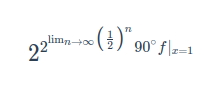

Processed image shape: torch.Size([1, 3, 384, 384])
2 ^ { 2 ^ { \operatorname* { l i m } _ { n \rarr \infin } \left ( { \frac { 1 } { 2 } } \right ) ^ { n } } 9 0 ^ { \circ } f | _ { x = 1 } }


In [10]:
image_path = "../data/test_img/a.png"
display(IPython.display.Image(image_path))
pred_str = inference(model, image_path, tokenizer, device)
print(pred_str)

$$
2 ^ { 2 ^ { \operatorname* { l i m } _ { n \rarr \infin } \left ( { \frac { 1 } { 2 } } \right ) ^ { n } } 9 0 ^ { \circ } f | _ { x = 1 } }
$$


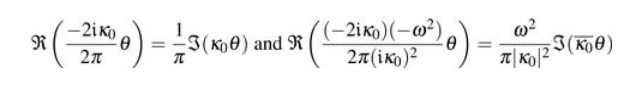

\Re \left ( \frac { - 2 \mathrm { i } \kappa _ { 0 } } { 2 \pi } \theta \right ) = \frac { 1 } { \pi } \Im ( \kappa _ { 0 } \theta ) ~ \mathrm { a n d } ~ \Re \left ( \frac { ( - 2 \mathrm { i } \kappa _ { 0 } ) ( - \varpi ^ { 2 } ) } { 2 \pi ( \mathrm { i } \kappa _ { 0 } ) ^ { 2 } } \theta \right ) = \frac { \omega ^ { 2 } } { \pi | \kappa _ { 0 } | ^ { 2 } } \Im ( \overline { \kappa _ { 0 } } \theta )


In [4]:
image_path = "../data/test_img/b.png"
display(IPython.display.Image(image_path))
pred_str = inference(model, image_path, tokenizer, device)
print(pred_str)

$$
\Re \left ( \frac { - 2 \mathrm { i } \kappa _ { 0 } } { 2 \pi } \theta \right ) = \frac { 1 } { \pi } \Im ( \kappa _ { 0 } \theta ) ~ \mathrm { a n d } ~ \Re \left ( \frac { ( - 2 \mathrm { i } \kappa _ { 0 } ) ( - \varpi ^ { 2 } ) } { 2 \pi ( \mathrm { i } \kappa _ { 0 } ) ^ { 2 } } \theta \right ) = \frac { \omega ^ { 2 } } { \pi | \kappa _ { 0 } | ^ { 2 } } \Im ( \overline { \kappa _ { 0 } } \theta )
$$


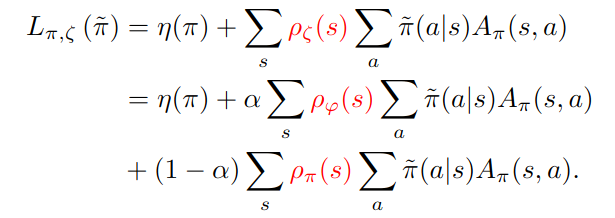

\begin{array} { l } { L _ { \pi, \zeta } \left ( \tilde { \pi } \right ) = \eta ( \pi ) + \sum _ { s } \rho _ { \zeta } ( s ) \sum _ { a } \tilde { \pi } ( a | s ) A _ { \pi } ( s, a ) } \\ { = \eta ( \pi ) + \alpha \sum _ { s } \rho _ { \varphi } ( s ) \sum _ { a } \tilde { \pi } ( a | s ) A _ { \pi } ( s, a ) } \\ { + ( 1 - \alpha ) \sum _ { s } \rho _ { \pi } ( s ) \sum _ { a } \tilde { \pi } ( a | s ) A _ { \pi } ( s, a ). } \end{array}


In [5]:
image_path = "../data/test_img/c.jpg"
display(IPython.display.Image(image_path))
pred_str = inference(model, image_path, tokenizer, device)
print(pred_str)

$$
\begin{array} { l } { L _ { \pi, \zeta } \left ( \tilde { \pi } \right ) = \eta ( \pi ) + \sum _ { s } \rho _ { \zeta } ( s ) \sum _ { a } \tilde { \pi } ( a | s ) A _ { \pi } ( s, a ) } \\ { = \eta ( \pi ) + \alpha \sum _ { s } \rho _ { \varphi } ( s ) \sum _ { a } \tilde { \pi } ( a | s ) A _ { \pi } ( s, a ) } \\ { + ( 1 - \alpha ) \sum _ { s } \rho _ { \pi } ( s ) \sum _ { a } \tilde { \pi } ( a | s ) A _ { \pi } ( s, a ). } \end{array}
$$


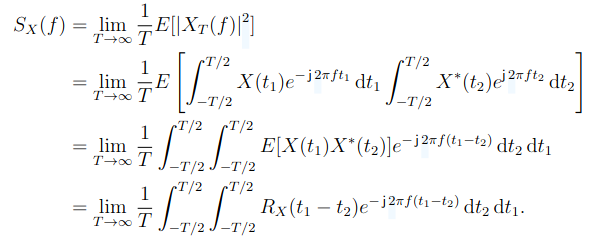

\begin{array} { r l } { S _ { X } ( f ) } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } E [ | X _ { T } ( f ) | ^ { 2 } ] } \\ { } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } E \left [ \int _ { - T / 2 } ^ { T / 2 } X ( t _ { 1 } ) e ^ { - \mathrm { j } ~ 2 \pi f t _ { 1 } } ~ \mathrm { d } t _ { 1 } \int _ { - T / 2 } ^ { T / 2 } X ^ { * } ( t _ { 2 } ) e ^ { \mathrm { j } ~ 2 \pi f t _ { 2 } } ~ \mathrm { d } t _ { 2 } \right ] } \\ { } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } \int _ { - T / 2 } ^ { T / 2 } \int _ { - T / 2 } ^ { T / 2 } E [ X ( t _ { 1 } ) X ^ { * } ( t _ { 2 } ) ] e ^ { - \mathrm { j } ~ 2 \pi f ( t _ { 1 } - t _ { 2 } ) } ~ \mathrm { d } t _ { 2 } ~ \mathrm { d } t _ { 1 } } \\ { } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } \int _ { - T / 2 } ^ { T / 2 } \int _ { - T / 2 } ^ { T / 2 } R _ { X } ( t _ { 1 } - t _ { 2 } ) e ^ { - \mathrm { j } ~ 2 \pi f ( t _ { 

In [6]:
image_path = "../data/test_img/d.png"
display(IPython.display.Image(image_path))
pred_str = inference(model, image_path, tokenizer, device)
print(pred_str)

$$
\begin{array} { r l } { S _ { X } ( f ) } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } E [ | X _ { T } ( f ) | ^ { 2 } ] } \\ { } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } E \left [ \int _ { - T / 2 } ^ { T / 2 } X ( t _ { 1 } ) e ^ { - \mathrm { j } ~ 2 \pi f t _ { 1 } } ~ \mathrm { d } t _ { 1 } \int _ { - T / 2 } ^ { T / 2 } X ^ { * } ( t _ { 2 } ) e ^ { \mathrm { j } ~ 2 \pi f t _ { 2 } } ~ \mathrm { d } t _ { 2 } \right ] } \\ { } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } \int _ { - T / 2 } ^ { T / 2 } \int _ { - T / 2 } ^ { T / 2 } E [ X ( t _ { 1 } ) X ^ { * } ( t _ { 2 } ) ] e ^ { - \mathrm { j } ~ 2 \pi f ( t _ { 1 } - t _ { 2 } ) } ~ \mathrm { d } t _ { 2 } ~ \mathrm { d } t _ { 1 } } \\ { } & { = \operatorname* { l i m } _ { T \rarr \infin } \frac { 1 } { T } \int _ { - T / 2 } ^ { T / 2 } \int _ { - T / 2 } ^ { T / 2 } R _ { X } ( t _ { 1 } - t _ { 2 } ) e ^ { - \mathrm { j } ~ 2 \pi f ( t _ { 1 } - t _ { 2 } ) } ~ \mathrm { d } t _ { 2 } ~ \mathrm { d } t _ { 1 }. } \end{array}
$$
